<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Intrinsic Validation 3 - BSM Extension: Sterile Neutrino
---
This notebook contains the physical propagation scenarios for the Sterile Neutrino extension. The Standard-Model limit, solar propagation, Earth propagation, solar-to-detector propagation and atmospheric propagation are kept here. Numerical convergence, perturbative controls, and the `RuntimeContext` are specified explicitly by the configuration and tolerances below.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Standard-Model-Limit) | **Standard Model Limit** |
| [4](#4.-Solar-Propagation) | **Solar Propagation** |
| [5](#5.-Pure-Flavour-States-Through-Earth) | **Pure Flavour States Through Earth** |
| [6](#6.-Solar-Neutrinos-to-the-Detector) | **Solar Neutrinos to the Detector** |
| [7](#7.-Atmospheric-Propagation) | **Atmospheric Propagation** |
| [8](#8.-Summary) | **Summary** |


## 0. Theoretical Framework
---




### 0.1 The $3+1$ Sterile-Neutrino Model

The $3+1$ scheme adds one sterile flavour state $\nu_s$ and one mass eigenstate $\nu_4$ to the three-flavour framework [1]. Flavour and mass states are related by a unitary $4\times4$ matrix,

$$
|\nu_\alpha\rangle=\sum_{i=1}^{4}U_{\alpha i}^{*}|\nu_i\rangle,
\qquad
\alpha\in\{e,\mu,\tau,s\}.
$$

TPeanuts augments the standard mixing parameters with $\theta_{14}$, $\theta_{24}$, $\theta_{34}$, the phases $\delta_{14}$, $\delta_{24}$, $\delta_{34}$ and the additional splitting $\Delta m_{41}^{2}$. The vacuum Hamiltonian is

$$
H_{\rm vac}=\frac{1}{2E}U_4\,\operatorname{diag}\!\left(0,\Delta m_{21}^{2},\Delta m_{31}^{2},\Delta m_{41}^{2}\right)U_4^\dagger.
$$

The sterile state has no Standard-Model charged-current or neutral-current interaction. Before removing a common phase, the matter term is

$$
H_{\rm mat}=\operatorname{diag}(V_{\rm CC}+V_{\rm NC},V_{\rm NC},V_{\rm NC},0),
$$

where

$$
V_{\rm CC}=\sqrt{2}G_Fn_e,
\qquad
V_{\rm NC}=-\frac{G_F}{\sqrt{2}}n_n
$$

for neutrinos. Subtracting the unobservable common contribution $V_{\rm NC}I_4$ gives the reduced matter potential used by the propagation Hamiltonian,

$$
H_{\rm mat}^{\rm red}=\operatorname{diag}(V_{\rm CC},0,0,-V_{\rm NC}).
$$

Unlike the three-active-flavour case, the neutral-current term cannot be discarded: it produces a relative active-sterile phase. For antineutrinos the mixing matrix is complex-conjugated and both matter potentials change sign.

The benchmark `sterile_3p1_bestfit_giunti2017` uses $\theta_{14}=8.5^\circ$, $\theta_{24}=7.5^\circ$, $\theta_{34}=0$, vanishing additional CP phases and $\Delta m_{41}^{2}=1.7\,\mathrm{eV}^{2}$. These rounded values are inspired by the 2017 global $3+1$ analysis of Gariazzo *et al.* [2]. They should be treated as a reproducible validation benchmark rather than a current global best fit.


### 0.2 Sterile-Neutrino Support in TPeanuts

| Method | Vacuum | Solar | Earth | Atmosphere |
|---|---|---|---|---|
| Numerical / exact | Full $3+1$ support | Full $3+1$ support | Full $3+1$ support | Full $3+1$ support |
| Perturbative / adiabatic | No separate perturbative vacuum path | `adiabatic_exact` (LZ not supported) | Full $3+1$ support | Full $3+1$ support |

Vacuum propagation uses the exact mass-eigenstate phases and therefore needs no density perturbation. Solar `adiabatic_approximated` and its two-level Landau-Zener correction are restricted to three active flavours; sterile propagation uses `adiabatic_exact` or the coherent numerical evolutor. Earth and atmosphere support both segmented numerical and first-order perturbative evolution with four-dimensional Hamiltonians. When neutron-density information is available, the relative sterile neutral-current potential is included automatically.


### 0.3 Validation observables

The numerical result is the reference and the perturbative result is tested. We report

$$
|\Delta P|=|P_{\rm tested}-P_{\rm reference}|,
\qquad
\frac{|\Delta P|}{|P_{\rm reference}|},
$$

with the relative error evaluated only where $|P_{\rm reference}|\geq10^{-5}$. All normalization tests sum over the four detected flavours, including $\nu_s$.


### 0.4 Common simulation configuration

| Medium/Module | Attribute | Value |
|---|---|---|
| Core | Physics model | $3+1$ sterile-neutrino extension |
| Core | Sterile preset | `sterile_3p1_bestfit_giunti2017` [2] |
| Core | Flavour / mass dimension | $4 / 4$ |
| Core | Sterile splitting | $\Delta m_{41}^{2}=1.7\,\mathrm{eV}^{2}$ |
| Core | Active-sector ordering | Normal ordering [3] |
| Core | Legacy precision | `False` |
| Solar | Evolution methods / Landau-Zener | `numerical`, `adiabatic_exact` / unsupported for $3+1$ |
| Solar | Density / spectrum provider | `zenodo` / `legacy` |
| Solar | Sterile matter term | CC plus neutron-density-dependent NC term |
| Earth | Perturbative / density model | `even_power` / PREM provider |
| Earth | Numerical method | Midpoint, 400 steps in Sections 4-7 |
| Earth | Detector depth / reunitarize | $1000\,\mathrm{m}$ / `False` in basic cases |
| Atmosphere | Density model | Exponential, matter enabled |
| Atmosphere | Perturbative / numerical | 6 cubic segments / 600 midpoint steps |
| Config | Basic energy and angular grids | 90 points per axis |
| Config | Device / dtype | Runtime-resolved values printed below |
| Config | Relative-error threshold | $10^{-5}$ |

**References**

- [1] C. Giunti and T. Lasserre, *eV-scale sterile neutrinos*, Annu. Rev. Nucl. Part. Sci. **69**, 163-190 (2019), arXiv:1901.08330.
- [2] S. Gariazzo, C. Giunti, M. Laveder and Y. F. Li, *Updated global 3+1 analysis of short-baseline neutrino oscillations*, JHEP **06**, 135 (2017), arXiv:1703.00860.
- [3] I. Esteban *et al.*, *The fate of hints: updated global analysis of three-flavor neutrino oscillations*, JHEP **09**, 178 (2020), arXiv:2007.14792; NuFIT 5.2 release (2022).


## 1. Libraries




In [1]:
from __future__ import annotations
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (ABSOLUTE_THRESHOLD, FLAVOUR_LABELS, save_and_show, to_numpy, validation_metrics, validation_heatmap, validation_comparison_grid, validation_summary_plot)
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.profile import SolarMediumProfile
from tpeanuts.source.solar import SolarNeutrinoSource
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters
from tpeanuts.medium.atmosphere.evolutor import atmosphere_evolutor
from tpeanuts.medium.atmosphere.probability import atmosphere_probability_transition
from tpeanuts.util.context import RuntimeContext


## 2. Paths and Configuration




### 2.1 Paths

`load_notebook_config()` resolves the package directory and applies the common plotting, Torch and NumPy configuration. Following the notebook-relative convention, generated figures and tables are saved under `validation/intrinsic/`.

**Expected results:**<br>
- The package and output directories exist,
- The runtime device and dtype match the shared notebook configuration.


In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('validation', 'intrinsic')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')


Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\validation\intrinsic
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

The runtime-resolved configuration below is the single source of truth for all calculations. It instantiates the four-flavour preset `sterile_3p1_bestfit_giunti2017`, PREM-derived Earth inputs, solar electron and neutron densities, an exponential atmosphere and the common numerical grids described in Section 0.4.

**Expected results:**<br>
- All profiles load successfully.
- The PMNS and mass-spectrum dimensions are four
- Neutron densities are available where required
- Every probability tensor uses the same runtime context.


In [3]:
CDTYPE = torch.complex128 if context.dtype == torch.float64 else torch.complex64
STERILE_PRESET = 'sterile_3p1_bestfit_giunti2017'
STERILE_NULL_PRESET = 'sterile_3p1_null_mixing'
SM_PRESET = '_SM_NUFIT52_NO'
oscillation = PropagationConfig.oscillation_parameters_from_preset(STERILE_PRESET, context=context, antinu=False)
N_FLAVOURS = int(oscillation.pmns.n_flavours)
FLAVOUR_LABELS = [r'$\nu_e$', r'$\nu_\mu$', r'$\nu_\tau$', r'$\nu_s$']
FLAVOUR_COLOURS = ('C0', 'C1', 'C2', 'C3')
earth = EarthProfile(params=EarthParameters(density_provider='prem', profile_perturbative_name='even_power', profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False,"include_neutron": True,}), context=context)
solar_medium = SolarMediumProfile.default(context=context)
solar_source = SolarNeutrinoSource.default(context=context)
atmosphere = AtmosphereParameters(atmosphere_density_source='exponential', nsteps=600, matter=True, perturbative_segments=6, perturbative_degree=3)
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
LEGACY_PRECISION = False
REFERENCE_LABEL, TESTED_LABEL = 'numerical', 'perturbative'
BASIS = torch.eye(N_FLAVOURS, device=context.device, dtype=CDTYPE)
configuration_rows = [('Core','Physics model','3+1 sterile neutrino'),('Core','Sterile preset',oscillation.preset_name),('Core','Number of flavours',N_FLAVOURS),('Core','Ordering',oscillation.ordering),('Core','Delta m^2_41 [eV^2]',float(oscillation.mass_spectrum.DeltamSq41)),('Core','Legacy precision',LEGACY_PRECISION),('Solar','Evolution methods','numerical / adiabatic_exact'),('Solar','Landau-Zener','unsupported for 3+1'),('Solar','Density provider','zenodo'),('Solar','Spectrum provider','legacy'),('Solar','Neutron density available',solar_medium.density_n is not None),('Earth','Perturbative model',earth.params.profile_perturbative_name),('Earth','Density provider',earth.params.density_provider),('Earth','Numerical steps',N_EARTH_STEPS),('Earth','Detector depth [m]',DEPTH_M),('Earth','Reunitarize basic cases',False),('Atmosphere','Density model',atmosphere.atmosphere_density_source),('Atmosphere','Perturbative fit',f'{atmosphere.perturbative_segments} x degree {atmosphere.perturbative_degree}'),('Atmosphere','Numerical steps',atmosphere.nsteps),('Config','Grid points per basic axis',90),('Config','Device',str(context.device)),('Config','Real dtype',str(context.dtype)),('Config','Relative-error threshold',ABSOLUTE_THRESHOLD)]
display(pd.DataFrame(configuration_rows, columns=['Medium/Module','Attribute','Value']))


,Medium/Module,Attribute,Value
0,Core,Physics model,3+1 sterile neutrino
1,Core,Sterile preset,sterile_3p1_bestfit_giunti2017
2,Core,Number of flavours,4
3,Core,Ordering,NO
4,Core,Delta m^2_41 [eV^2],1.7
5,Core,Legacy precision,False
6,Solar,Evolution methods,numerical / adiabatic_exact
7,Solar,Landau-Zener,unsupported for 3+1
8,Solar,Density provider,zenodo
9,Solar,Spectrum provider,legacy


### 2.3 Local Helpers

The reusable validation helpers compute absolute, thresholded-relative and normalization errors, and draw the common heatmaps and probability/error grids. Every physical scenario is self-contained after Sections 1 and 2 and writes its figures into `OUTPUT_DIR`.


In [4]:
summaries = []
ABSOLUTE_THRESHOLD = 1e-3
def record_metrics(case, reference, tested):
    row, absolute, relative = validation_metrics(case, reference, tested, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, absolute_threshold=ABSOLUTE_THRESHOLD)
    summaries.append(row)
    display(pd.DataFrame([row]).set_index('case').style.format({c: '{:.3e}' for c, value in row.items() if isinstance(value, float)}))
    return absolute, relative

def atmosphere_detector_grid(method):
    S_atm, _ = atmosphere_evolutor(oscillation, E_det[:,None], 25.0, theta_det[None,:], DEPTH_M/1000.0, atmosphere=atmosphere, context=context, method=method, legacy_precision=LEGACY_PRECISION)
    angle_results = []
    for i_theta, theta in enumerate(theta_det):
        eta = torch.pi - torch.deg2rad(theta)
        states = []
        for state in BASIS:
            surface_state = torch.matmul(S_atm[:,i_theta], state)
            states.append(earth_probability_state(surface_state, earth, oscillation, E_det[:,None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_det.numel(),N_FLAVOURS))
        angle_results.append(torch.stack(states))
    return torch.stack(angle_results, dim=2)

def solar_detector_grid(method):
    return torch.stack([earth_probability_state(solar_weights, earth, oscillation, E_solar[:,None], eta, DEPTH_M, method=method, massbasis=True, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_solar.numel(),N_FLAVOURS) for eta in eta_solar], dim=1)

def earth_flavour_grid(method):
    per_state = []
    for state in BASIS:
        per_eta = [earth_probability_state(state, earth, oscillation, E_earth[:, None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_earth.numel(), N_FLAVOURS) for eta in eta_earth]
        per_state.append(torch.stack(per_eta, dim=1))
    return torch.stack(per_state)

def solar_earth_sm_limit_grid(oscillation_parameters, mass_weights):
    n_flavours = int(oscillation_parameters.pmns.n_flavours)
    return torch.stack([earth_probability_state(mass_weights, earth, oscillation_parameters, E_sm_limit[:,None], eta, DEPTH_M, method='analytical', massbasis=True, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_sm_limit.numel(),n_flavours) for eta in eta_sm_limit], dim=1)


## 3. Standard Model Limit

This test verifies the zero-active-sterile-mixing limit across the complete solar-Earth chain. The reference is the ordinary three-flavour Standard Model. The tested branch uses `sterile_3p1_null_mixing`, for which $\theta_{14}=\theta_{24}=\theta_{34}=0$ while the calculation still runs through the four-flavour PMNS, mass-spectrum and Hamiltonian machinery.

Both branches use `adiabatic_exact` for $^8$B production and perturbative Earth propagation with `reunitarize=False`. The three-flavour reference is embedded as

$$
\left(P_e,P_\mu,P_\tau\right)_{\rm SM}
\longrightarrow
\left(P_e,P_\mu,P_\tau,0\right)_{\rm SM},
$$

so it can be compared directly with the four-flavour result. The value of $\Delta m_{41}^{2}$ is irrelevant in this limit because $\nu_4$ is completely decoupled.

**Expected results:**<br>
- Active probabilities should agree to floating-point precision.
- $P_s$ should remain zero and both embedded probability vectors should sum to one.
- Any larger discrepancy would indicate that the sterile kinetic or neutral-current term fails to decouple when the active-sterile angles vanish.


,max_abs,mean_abs,max_rel,mean_rel,normalization_Standard Model + zero sterile,normalization_sterile_3p1_null_mixing,relative_points,absolute_threshold
case,,,,,,,,
solar-Earth sterile null-mixing limit,1.258e-09,1.043e-10,3.639e-09,4.200e-10,5.213e-04,5.213e-04,2.430e+04,1.000e-03


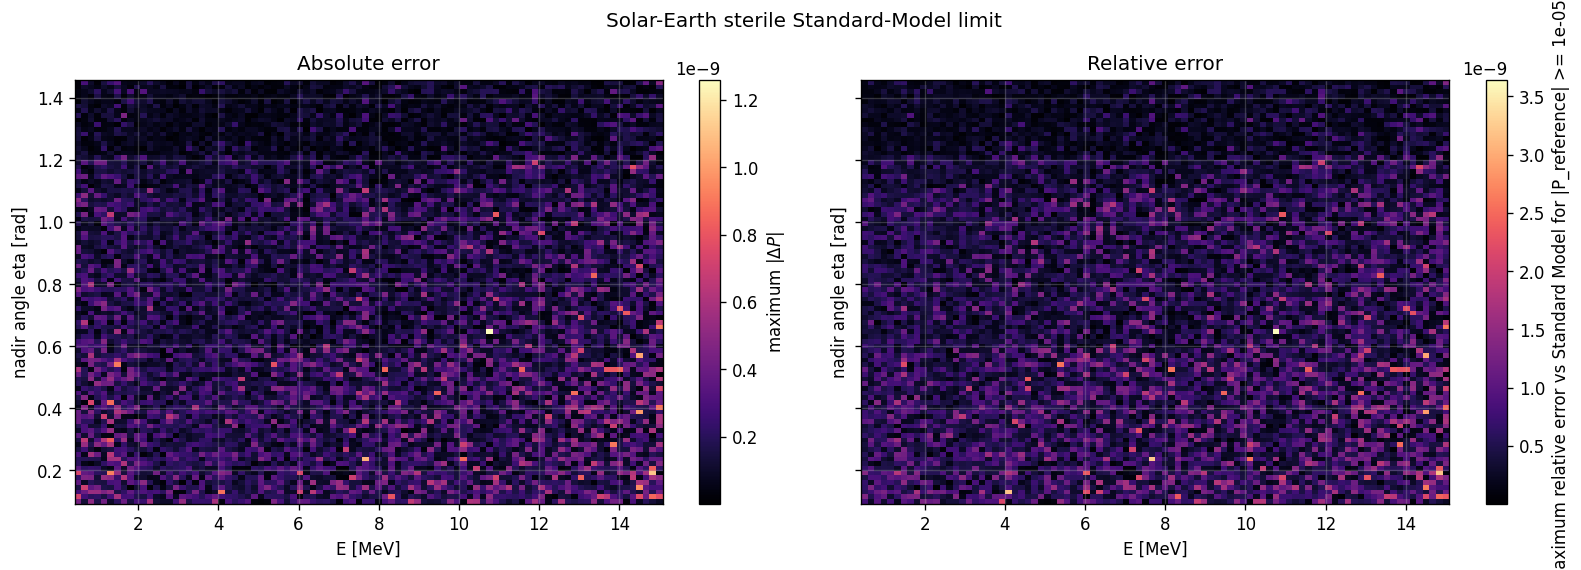

v:\output\validation\intrinsic\intrinsic3_sterile_fig3_sm_limit.png


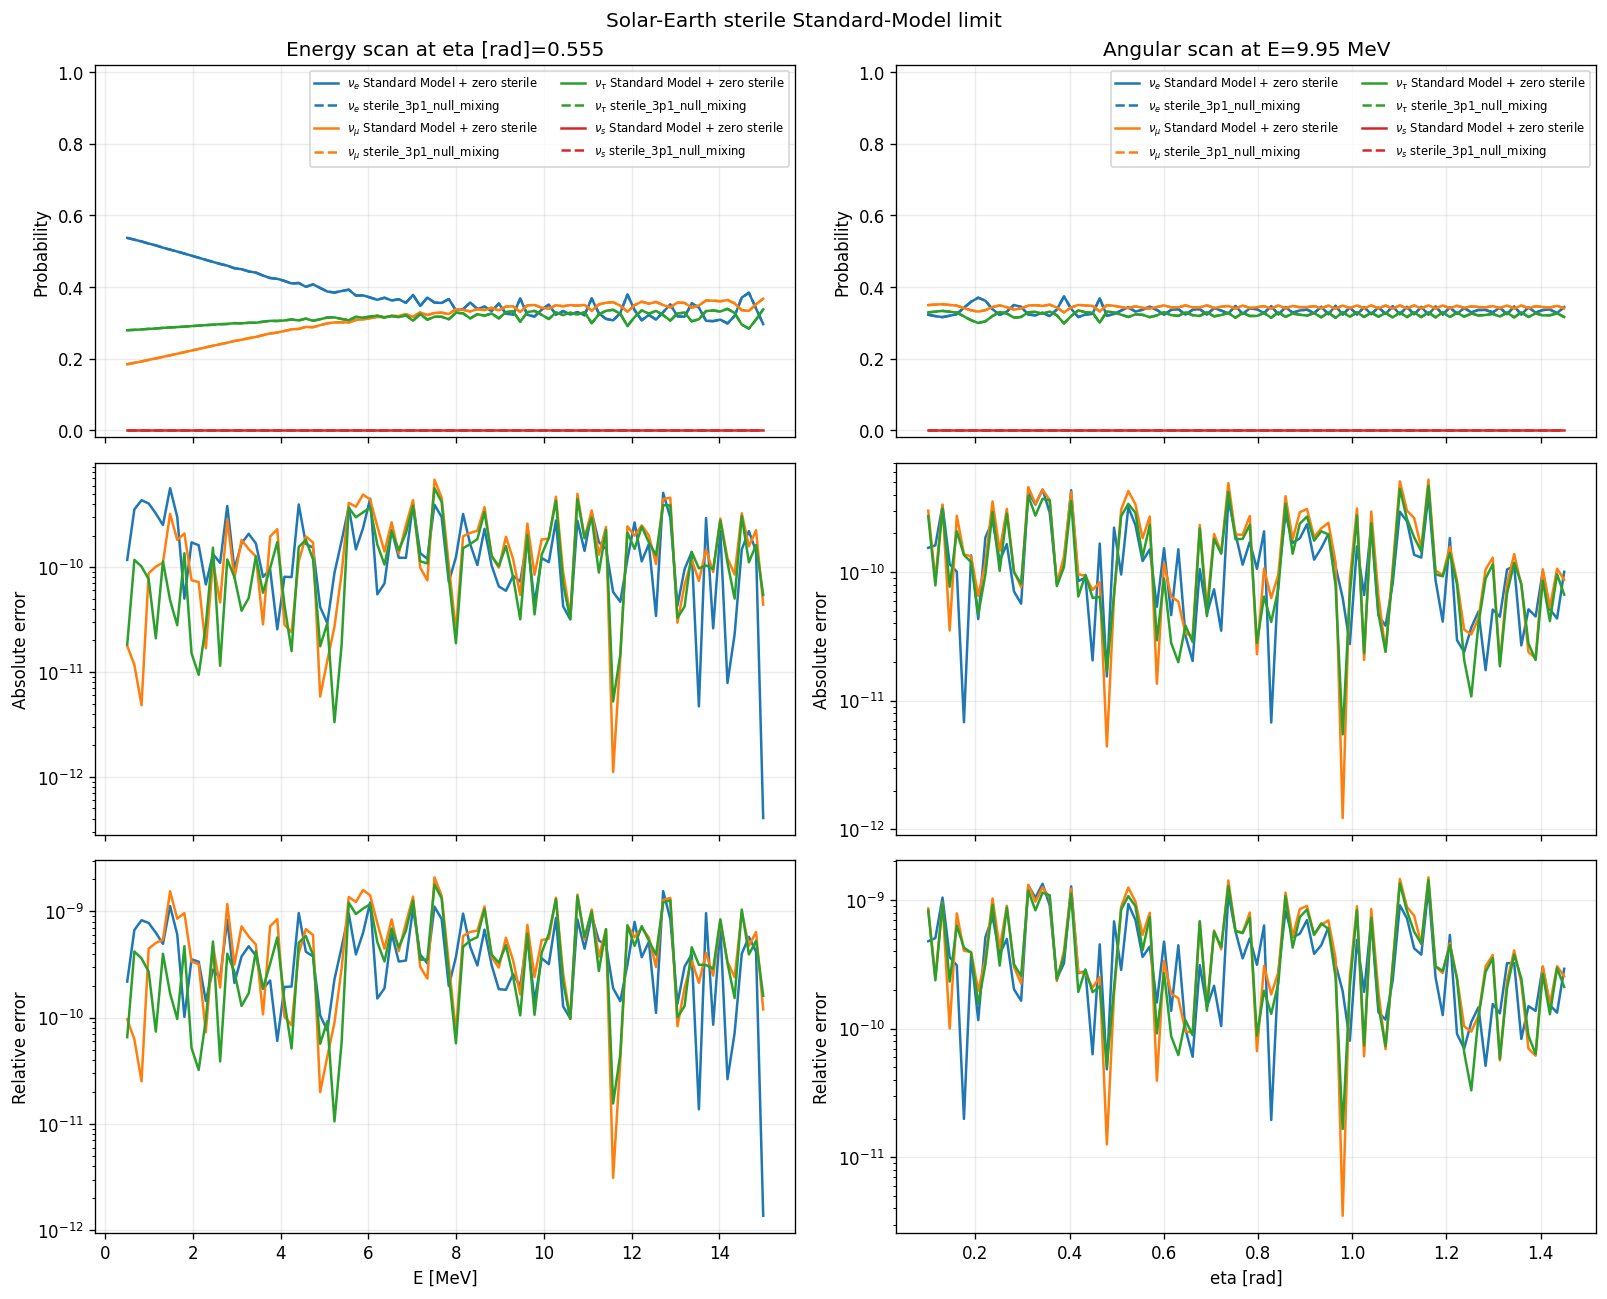

v:\output\validation\intrinsic\intrinsic3_sterile_fig3b_sm_limit_slices.png


In [5]:
oscillation_sm = PropagationConfig.oscillation_parameters_from_preset(SM_PRESET, context=context, antinu=False)
oscillation_sterile_sm_limit = PropagationConfig.oscillation_parameters_from_preset(STERILE_NULL_PRESET, context=context, antinu=False)
E_sm_limit = torch.linspace(0.5, 15.0, 90, device=context.device, dtype=context.dtype)
eta_sm_limit = torch.linspace(0.10, 1.45, 90, device=context.device, dtype=context.dtype)
sm_limit_weights_reference = solar_probability_mass(oscillation_sm, E_sm_limit, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
sm_limit_weights_tested = solar_probability_mass(oscillation_sterile_sm_limit, E_sm_limit, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
sm_limit_reference_active = solar_earth_sm_limit_grid(oscillation_sm, sm_limit_weights_reference)
sm_limit_reference = torch.cat([sm_limit_reference_active, torch.zeros_like(sm_limit_reference_active[...,:1])], dim=-1)
sm_limit_tested = solar_earth_sm_limit_grid(oscillation_sterile_sm_limit, sm_limit_weights_tested)
sm_limit_row, sm_limit_abs, sm_limit_rel = validation_metrics('solar-Earth sterile null-mixing limit', sm_limit_reference, sm_limit_tested, reference_label='Standard Model + zero sterile', tested_label=STERILE_NULL_PRESET, absolute_threshold=ABSOLUTE_THRESHOLD)
display(pd.DataFrame([sm_limit_row]).set_index('case').style.format('{:.3e}'))
validation_heatmap(sm_limit_abs.amax(dim=-1), sm_limit_rel.amax(dim=-1), E_sm_limit, eta_sm_limit, title='Solar-Earth sterile Standard-Model limit', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic3_sterile_fig3_sm_limit.png', output_dir=OUTPUT_DIR, reference_label='Standard Model', show_plots=config.show_plots)
validation_comparison_grid(sm_limit_reference, sm_limit_tested, E_sm_limit, eta_sm_limit, 0.55, 10.0, title='Solar-Earth sterile Standard-Model limit', angle_label='eta [rad]', filename='intrinsic3_sterile_fig3b_sm_limit_slices.png', output_dir=OUTPUT_DIR, reference_label='Standard Model + zero sterile', tested_label=STERILE_NULL_PRESET, labels=FLAVOUR_LABELS, colours=FLAVOUR_COLOURS, show_plots=config.show_plots)


## 4. Solar Propagation

This comparison evaluates the four mass-eigenstate probabilities at the solar surface for $^8$B neutrinos using the two methods that support the $3+1$ model:

- `numerical` coherently propagates the production state through the discretized electron and neutron density profiles and projects it onto the four vacuum mass eigenstates; it is the reference.
- `adiabatic_exact` diagonalizes the complete local $4\times4$ Hamiltonian at every production point while assuming adiabatic following.

After averaging over the normalized radial production distribution,

$$
P_i^{\odot,\mathrm{ad}}(E)=\int_0^{R_\odot}dr\,f_{8B}(r)|U^m_{ei}(r,E)|^2,
\qquad i=1,\ldots,4.
$$

The sequential effective-angle method and its two-level Landau-Zener correction are omitted because they do not generalize to the fourth instantaneous eigenstate.

**Expected results:**<br>
- `adiabatic_exact` should follow the numerical calculation where solar evolution is adiabatic.
- All four weights must remain finite, non-negative and normalized.
- The fourth weight measures production into the vacuum state carrying the sterile admixture; it need not vanish for the main benchmark.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_adiabatic_exact,relative_points,absolute_threshold
case,,,,,,,,
sterile solar surface: adiabatic_exact vs numerical,1.656e-02,3.404e-04,1.528e-01,2.159e-03,1.009e-06,4.441e-16,4.800e+02,1.000e-03


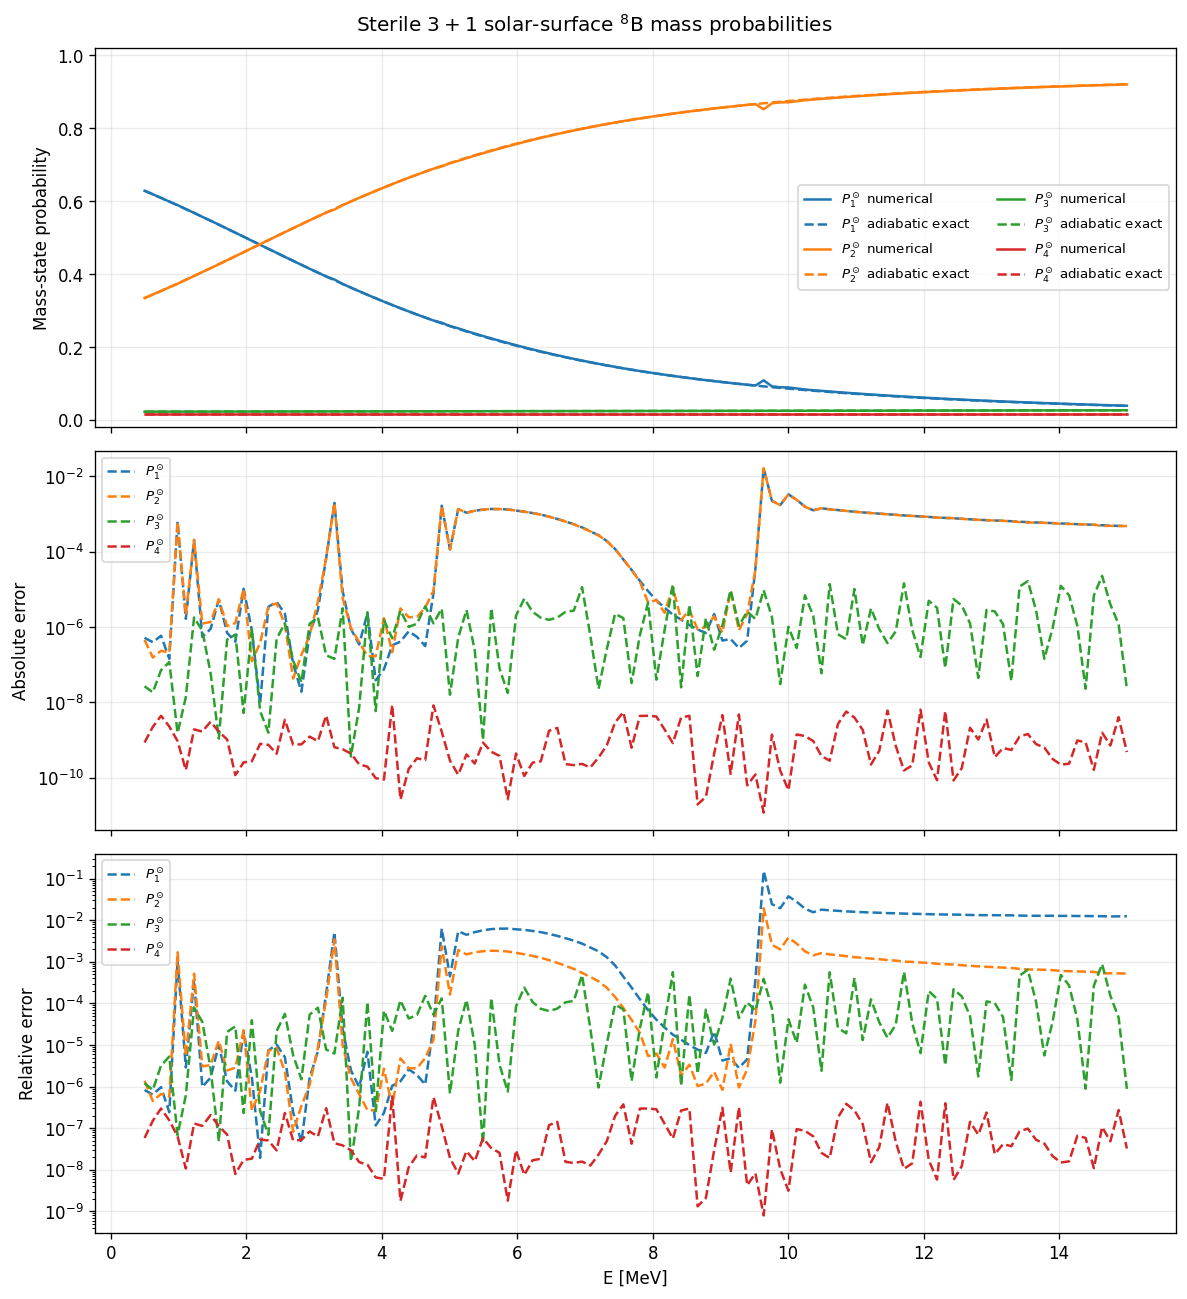

v:\output\validation\intrinsic\intrinsic3_sterile_fig4_solar_surface.png


In [6]:
E_solar_surface = torch.linspace(0.5, 15.0, 120, device=context.device, dtype=context.dtype)
solar_surface_reference = solar_probability_mass(oscillation, E_solar_surface, solar_medium, solar_source, '8B', method='numerical', numerical_sampling='midpoint', legacy_precision=LEGACY_PRECISION)
solar_surface_exact = solar_probability_mass(oscillation, E_solar_surface, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
solar_surface_row, solar_surface_abs, solar_surface_rel = validation_metrics('sterile solar surface: adiabatic_exact vs numerical', solar_surface_reference, solar_surface_exact, reference_label='numerical', tested_label='adiabatic_exact', absolute_threshold=ABSOLUTE_THRESHOLD)
display(pd.DataFrame([solar_surface_row]).set_index('case').style.format('{:.3e}'))
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
for mass_index, colour in enumerate(FLAVOUR_COLOURS):
    label = rf'$P_{{{mass_index + 1}}}^\odot$'
    axes[0].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_reference[:,mass_index]), color=colour, label=f'{label} numerical')
    axes[0].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_exact[:,mass_index]), '--', color=colour, label=f'{label} adiabatic exact')
    axes[1].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_abs[:,mass_index]), '--', color=colour, label=label)
    axes[2].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_rel[:,mass_index]), '--', color=colour, label=label)
axes[0].set_ylabel('Mass-state probability'); axes[0].set_ylim(-0.02, 1.02); axes[0].legend(fontsize=8, ncol=2)
axes[1].set_ylabel('Absolute error'); axes[1].set_yscale('log'); axes[1].legend(fontsize=8)
axes[2].set_ylabel('Relative error'); axes[2].set_yscale('log'); axes[2].set_xlabel('E [MeV]'); axes[2].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle(r'Sterile $3+1$ solar-surface $^8$B mass probabilities')
fig.tight_layout()
save_and_show('intrinsic3_sterile_fig4_solar_surface.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 5. Pure Flavour States Through Earth

The four coherent pure flavour states propagated independently are

$$
|\nu_e\rangle=(1,0,0,0)^T,\quad
|\nu_\mu\rangle=(0,1,0,0)^T,\quad
|\nu_\tau\rangle=(0,0,1,0)^T,\quad
|\nu_s\rangle=(0,0,0,1)^T.
$$

Each vector is propagated over an energy-nadir grid, testing every initial-flavour column and all four detected flavours. The Earth Hamiltonian includes the fourth mass splitting and the relative sterile neutral-current potential. Numerical propagation uses 400 midpoint segments; the perturbative branch uses `reunitarize=False`.

**Expected results:**<br>
- Both methods must conserve the total active-plus-sterile probability.
- Matter-sensitive differences are expected for long trajectories, while the perturbative and numerical curves should reproduce the same active-sterile oscillation structure.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
pure flavour through Earth,2.328e-02,3.891e-04,4.712e-01,4.023e-03,1.711e-10,2.444e-02,120080,1.000e-03


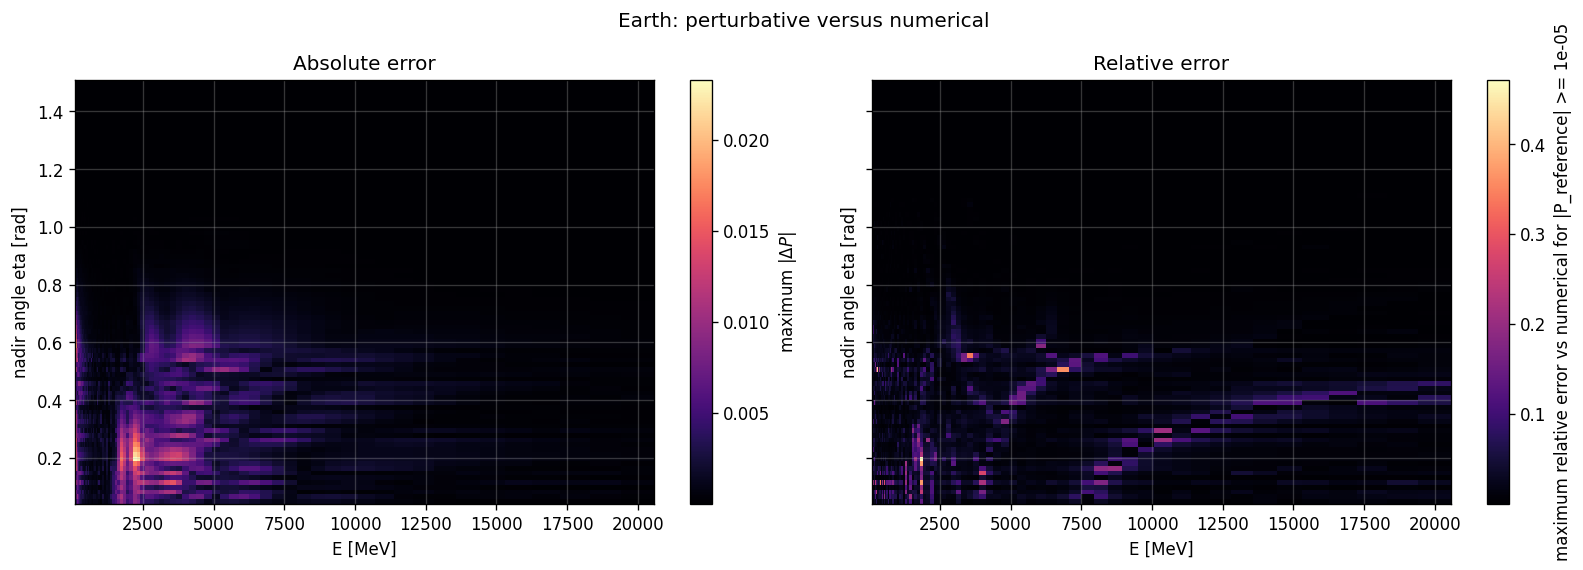

v:\output\validation\intrinsic\intrinsic3_sterile_fig5_earth.png


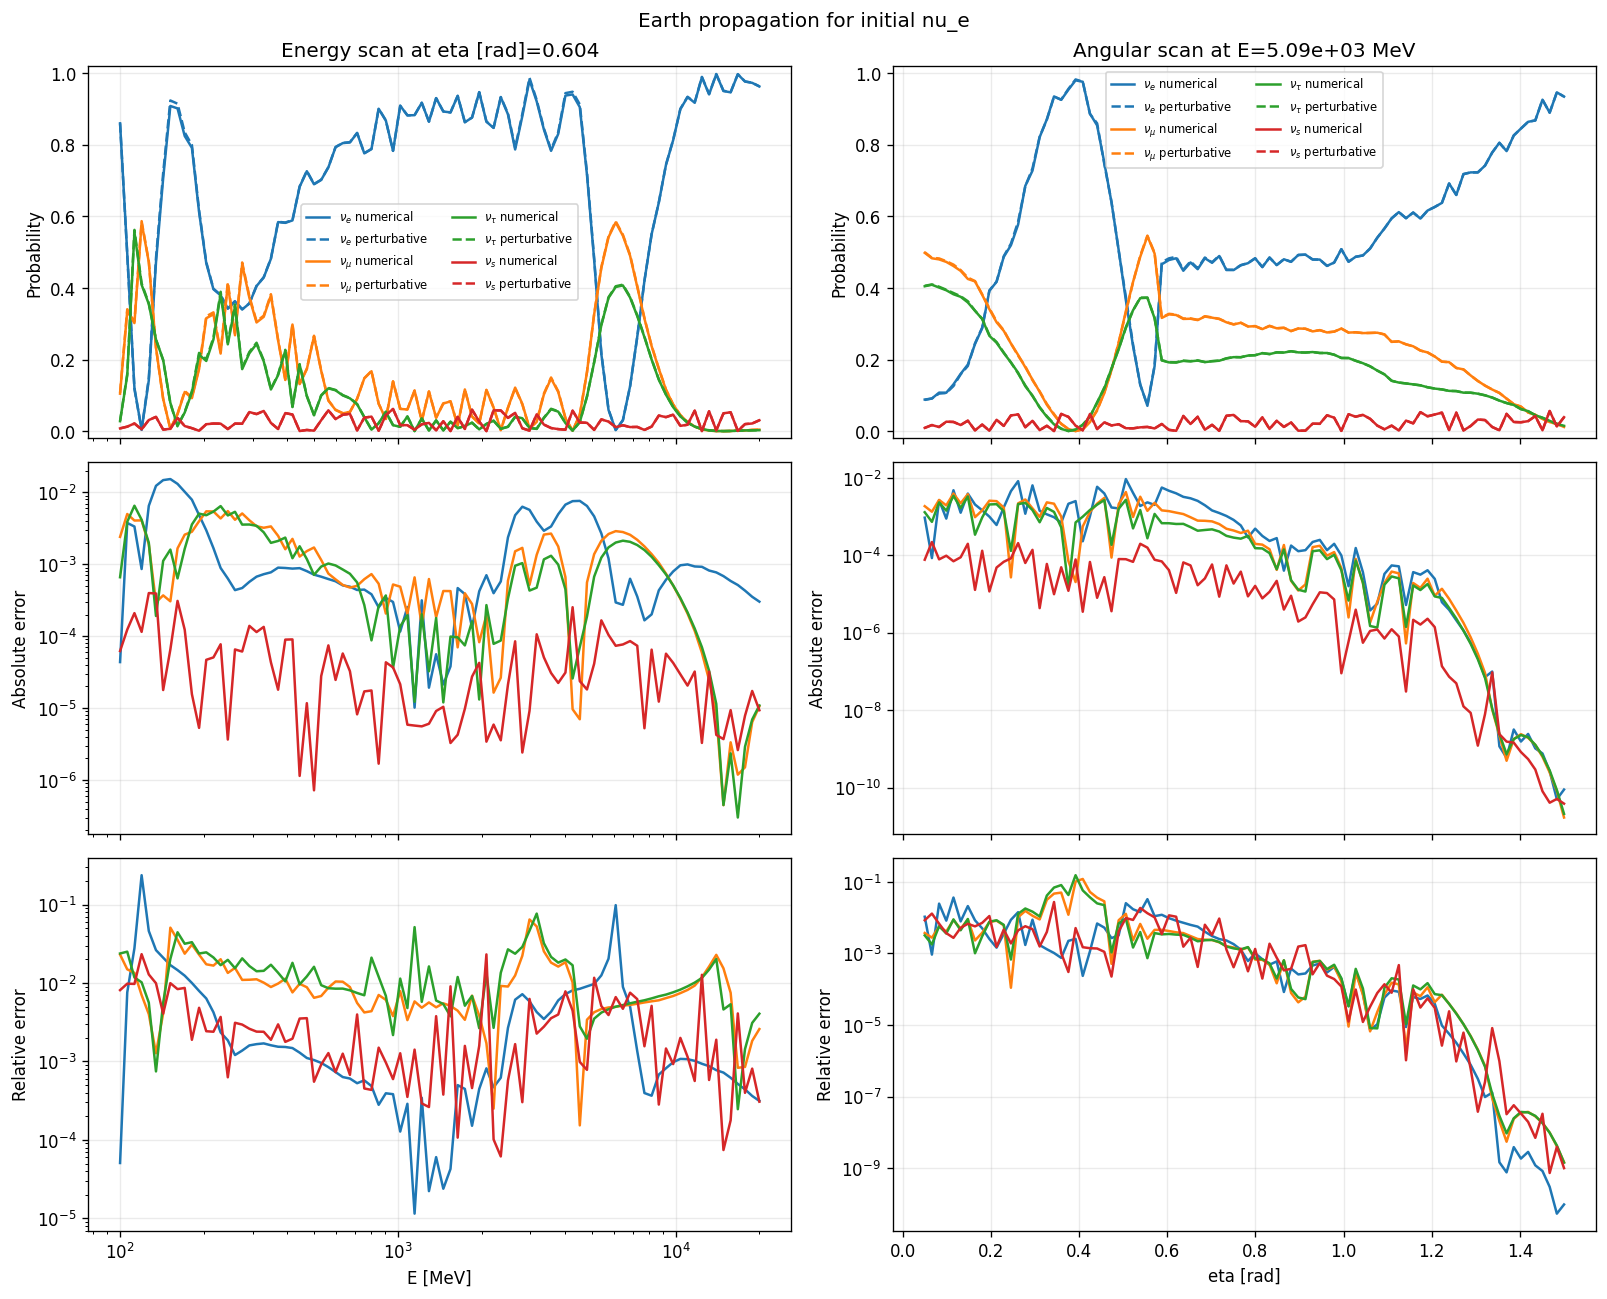

v:\output\validation\intrinsic\intrinsic3_sterile_fig5b_earth_slices.png


In [7]:
E_earth = torch.logspace(np.log10(100.0), np.log10(2.0e4), 90, device=context.device, dtype=context.dtype)
eta_earth = torch.linspace(0.05, 1.50, 90, device=context.device, dtype=context.dtype)
earth_reference = earth_flavour_grid('numerical')
earth_tested = earth_flavour_grid('analytical')
earth_abs, earth_rel = record_metrics('pure flavour through Earth', earth_reference, earth_tested)
validation_heatmap(earth_abs.amax(dim=(0,3)), earth_rel.amax(dim=(0,3)), E_earth, eta_earth, title='Earth: perturbative versus numerical', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic3_sterile_fig5_earth.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(earth_reference[0], earth_tested[0], E_earth, eta_earth, 0.60, 5000.0, title='Earth propagation for initial nu_e', angle_label='eta [rad]', filename='intrinsic3_sterile_fig5b_earth_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, labels=FLAVOUR_LABELS, colours=FLAVOUR_COLOURS, show_plots=config.show_plots)


## 6. Solar Neutrinos to the Detector

Solar $^8$B neutrinos are converted by the sterile-compatible `adiabatic_exact` calculation into four incoherent mass-eigenstate weights. These common weights are propagated through Earth to the detector; only the Earth method differs between the numerical reference and perturbative tested branch. All detected probabilities include $(P_e,P_\mu,P_\tau,P_s)$.

**Expected results:**<br>
- The four probabilities remain normalized.
- Earth regeneration may redistribute both active and sterile components.
- Perturbative-numerical differences should remain small compared with the physical matter effect.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
solar production to detector,8.599e-03,2.271e-04,2.556e-02,7.683e-04,3.492e-08,5.015e-04,32400,1.000e-03


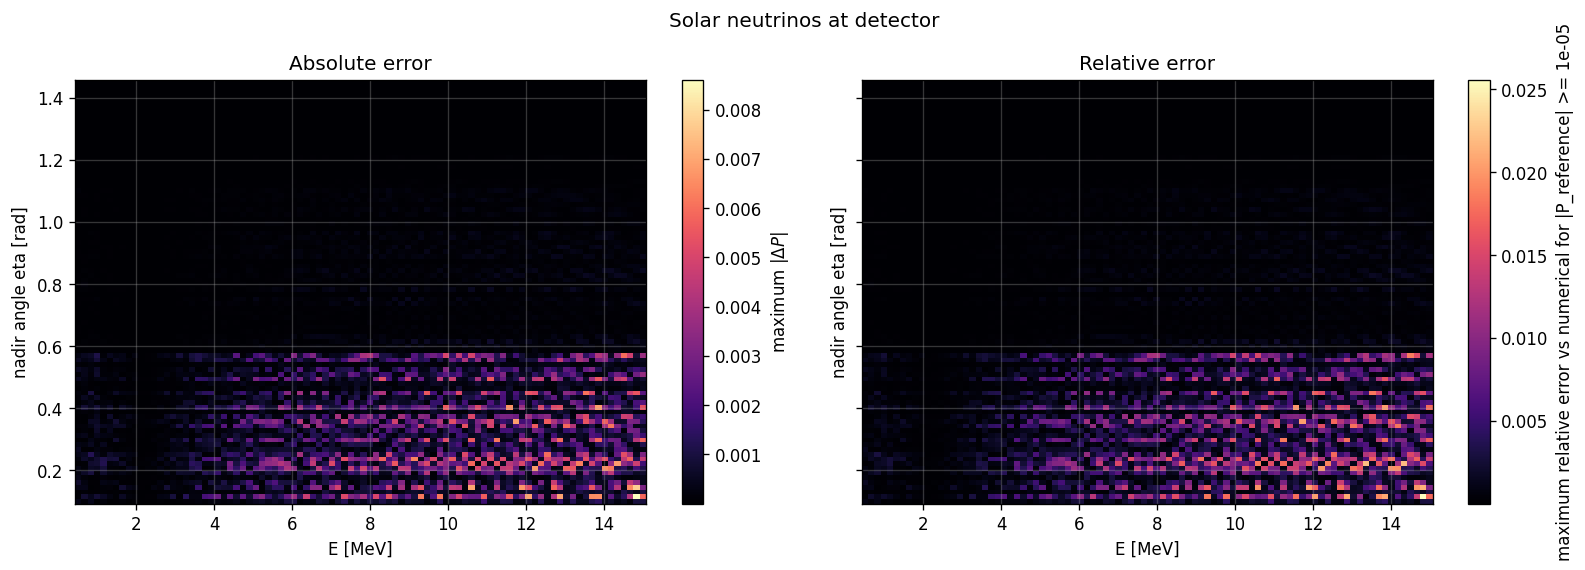

v:\output\validation\intrinsic\intrinsic3_sterile_fig6_solar.png


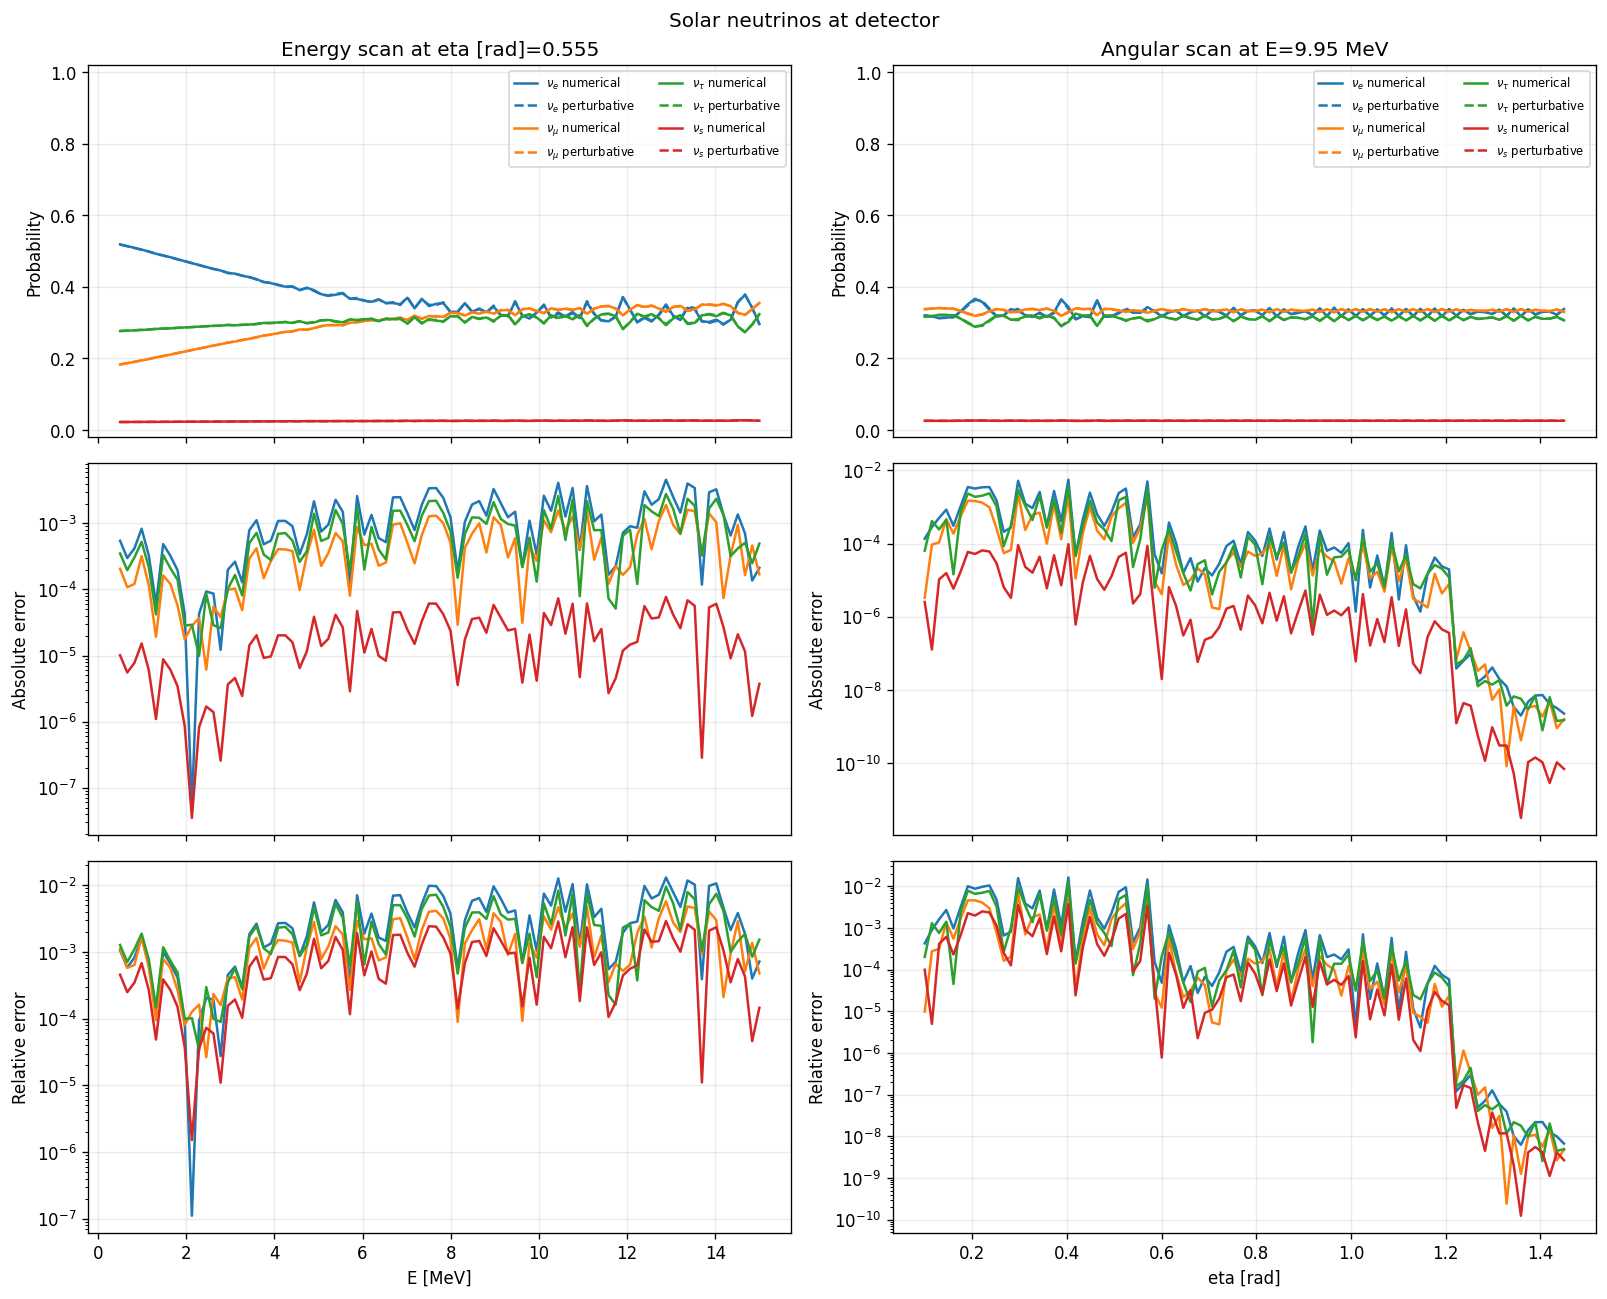

v:\output\validation\intrinsic\intrinsic3_sterile_fig6b_solar_slices.png


In [8]:
E_solar = torch.linspace(0.5, 15.0, 90, device=context.device, dtype=context.dtype)
eta_solar = torch.linspace(0.10, 1.45, 90, device=context.device, dtype=context.dtype)
solar_weights = solar_probability_mass(oscillation, E_solar, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
solar_reference = solar_detector_grid('numerical')
solar_tested = solar_detector_grid('analytical')
solar_abs, solar_rel = record_metrics('solar production to detector', solar_reference, solar_tested)
validation_heatmap(solar_abs.amax(dim=-1), solar_rel.amax(dim=-1), E_solar, eta_solar, title='Solar neutrinos at detector', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic3_sterile_fig6_solar.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(solar_reference, solar_tested, E_solar, eta_solar, 0.55, 10.0, title='Solar neutrinos at detector', angle_label='eta [rad]', filename='intrinsic3_sterile_fig6b_solar_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, labels=FLAVOUR_LABELS, colours=FLAVOUR_COLOURS, show_plots=config.show_plots)


## 7. Atmospheric Propagation


### 7.1 Atmospheric neutrinos to the surface

The complete coherent $3\times3$ flavour-transition matrix is compared at the Earth surface. The perturbative atmosphere uses six cubic local fits and the numerical reference uses 600 midpoint density segments. Both plotted errors are maximized over the complete transition matrix. The $3\times2$ grid selects initial $\nu_e$ and shows energy dependence near the horizon ($\theta=89^\circ$) and angular dependence near $E=10\,\mathrm{GeV}$.

**Expected results:**<br>

- Agreement should be especially strong because atmospheric electron density is low.
- Differences may grow near the horizon, where the atmospheric path is longest.
- Every transition-matrix column should sum to one.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
atmosphere production to surface,7.388e-09,2.539e-10,1.125e-07,2.892e-09,6.547e-12,7.610e-09,89344,1.000e-03


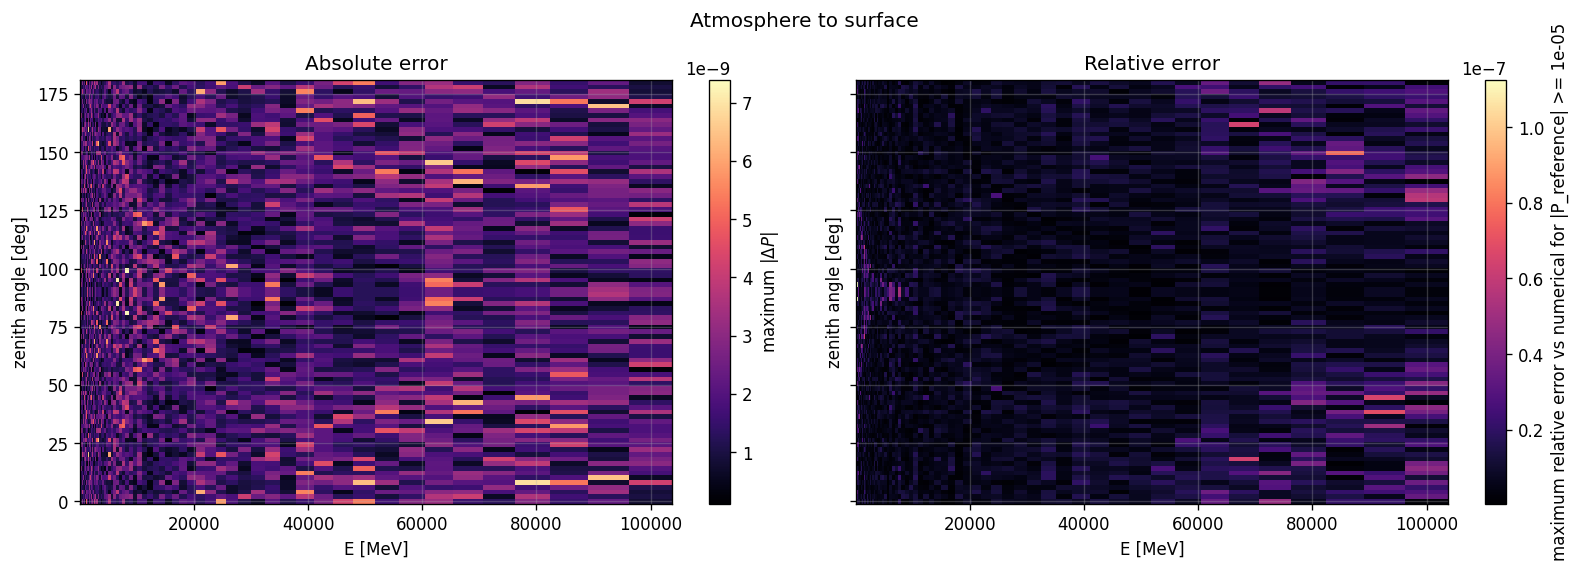

v:\output\validation\intrinsic\intrinsic3_sterile_fig71_surface.png


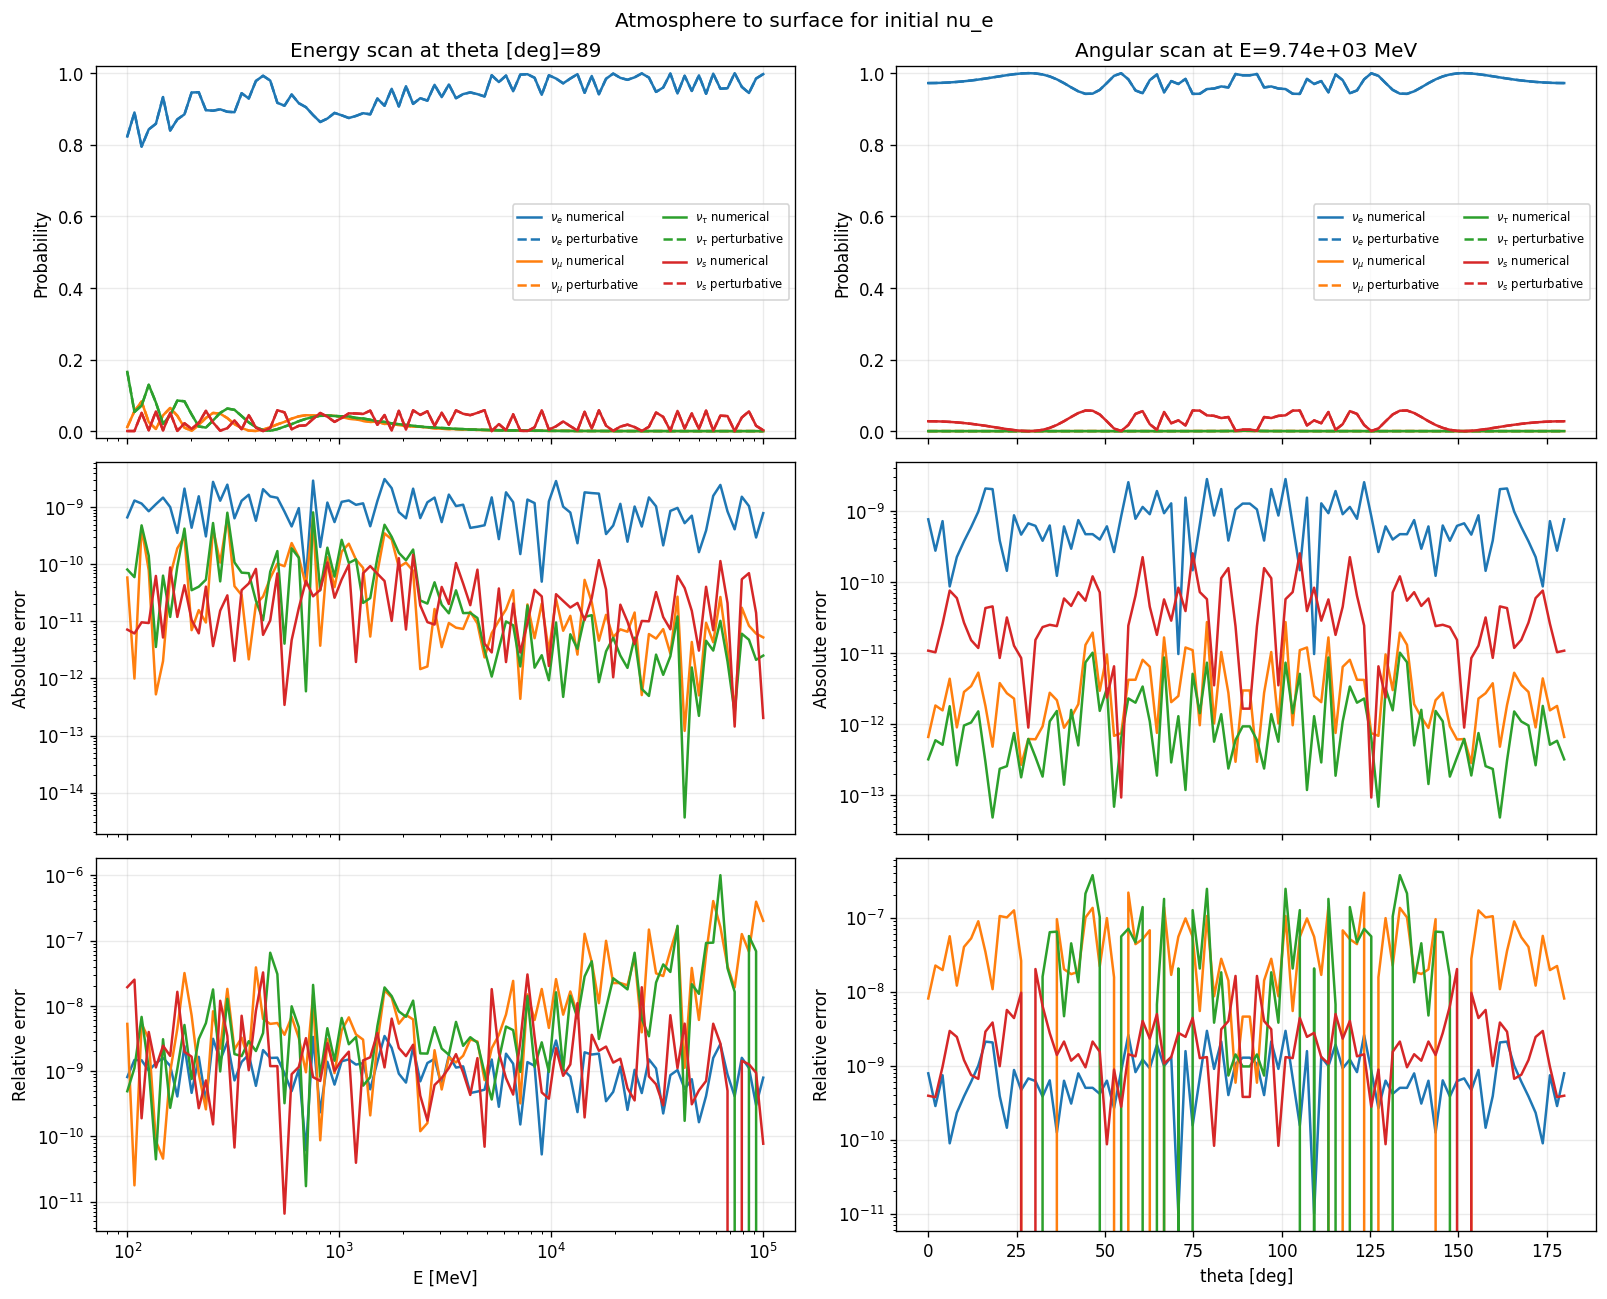

v:\output\validation\intrinsic\intrinsic3_sterile_fig71b_surface_slices.png


In [9]:
E_atm = torch.logspace(2.0, 5.0, 90, device=context.device, dtype=context.dtype)
theta_atm = torch.linspace(0.0, 180.0, 90, device=context.device, dtype=context.dtype)
atm_args = dict(oscillation=oscillation, E_MeV=E_atm[:,None], h_km=25.0, theta_deg=theta_atm[None,:], depth_km=DEPTH_M/1000.0, atmosphere=atmosphere, context=context, legacy_precision=LEGACY_PRECISION)
surface_reference = atmosphere_probability_transition(**atm_args, method='numerical')
surface_tested = atmosphere_probability_transition(**atm_args, method='analytical')
surface_abs, surface_rel = record_metrics('atmosphere production to surface', surface_reference, surface_tested)
validation_heatmap(surface_abs.amax(dim=(-2,-1)), surface_rel.amax(dim=(-2,-1)), E_atm, theta_atm, title='Atmosphere to surface', xlabel='E [MeV]', ylabel='zenith angle [deg]', filename='intrinsic3_sterile_fig71_surface.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(surface_reference[..., :,0], surface_tested[..., :,0], E_atm, theta_atm, 89.0, 1e4, title='Atmosphere to surface for initial nu_e', angle_label='theta [deg]', filename='intrinsic3_sterile_fig71b_surface_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, labels=FLAVOUR_LABELS, colours=FLAVOUR_COLOURS, show_plots=config.show_plots)


### 7.2 Atmospheric neutrinos to the underground detector

Atmosphere amplitudes act on each pure state first; the resulting coherent surface state is then propagated through Earth. The total probability is therefore not constructed by multiplying probability matrices. Parallel heatmaps summarize the maximum errors. The $3\times2$ grid selects initial $\nu_e$, an up-going trajectory at $\theta=150^\circ$, and an angular scan near $E=5\,\mathrm{GeV}$. Both basic branches use `reunitarize=False`.

**Expected results:**<br>

- Down-going events mainly test atmospheric propagation, whereas up-going events also test long Earth chords.
- Combined probabilities must remain normalized.
- The largest discrepancies are expected for up-going, matter-sensitive trajectories; this is the strongest end-to-end test because coherence is retained at the surface.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
atmosphere production to detector,2.294e-02,2.187e-04,4.875e-01,2.621e-03,1.660e-10,2.338e-02,109210,1.000e-03


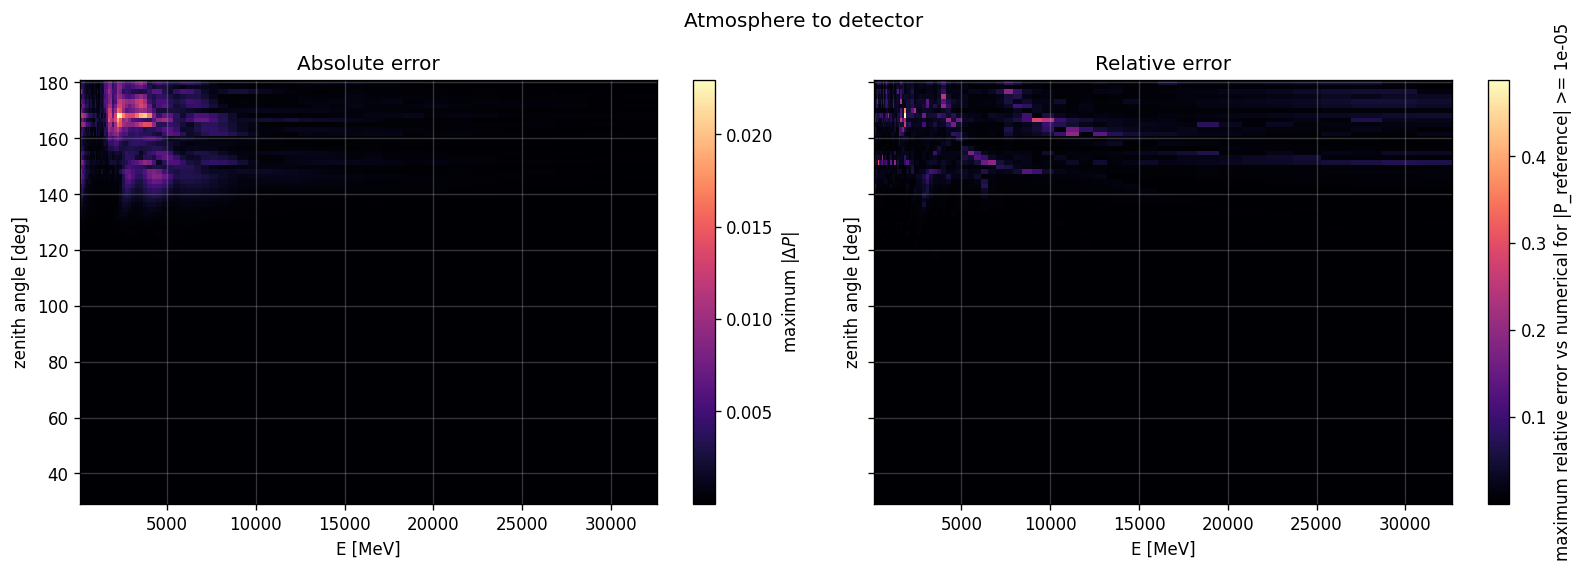

v:\output\validation\intrinsic\intrinsic3_sterile_fig72_detector.png


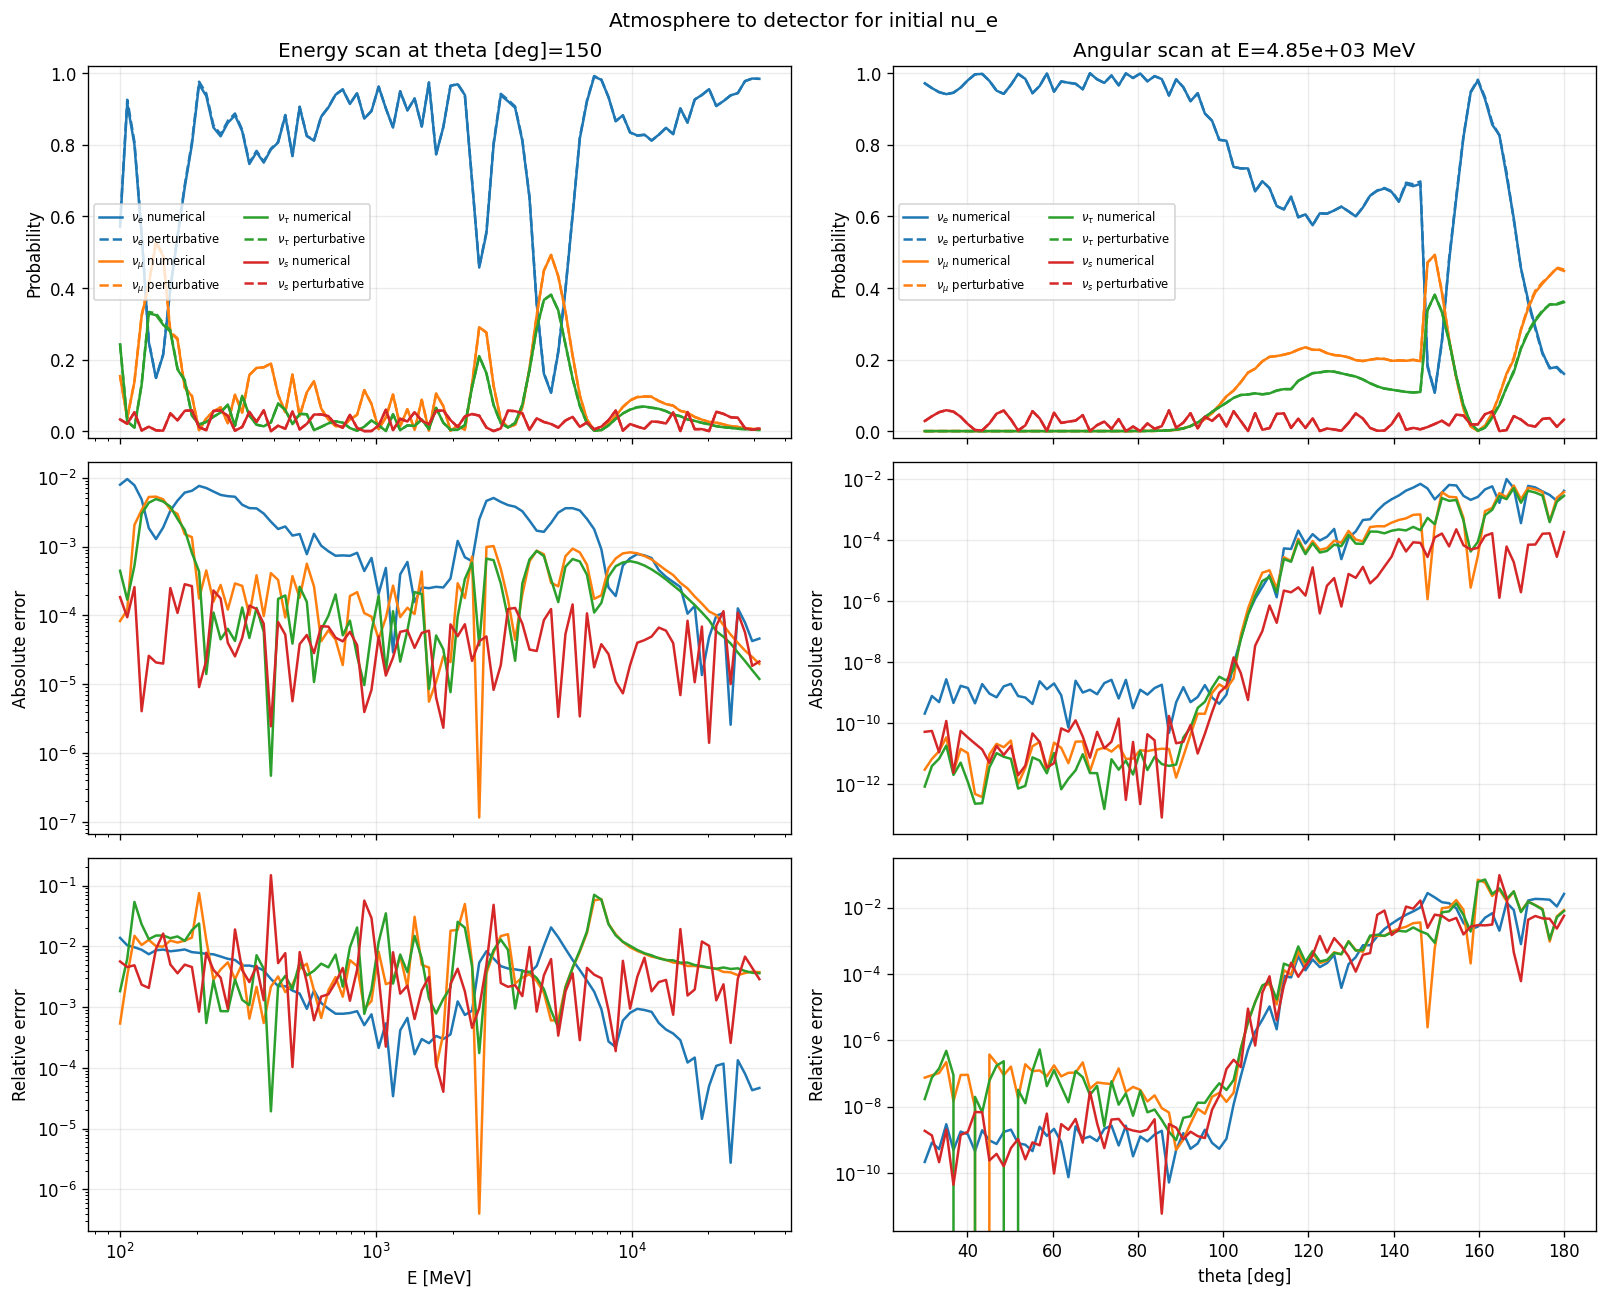

v:\output\validation\intrinsic\intrinsic3_sterile_fig72b_detector_slices.png


In [10]:
E_det = torch.logspace(2.0, 4.5, 90, device=context.device, dtype=context.dtype)
theta_det = torch.linspace(30.0, 180.0, 90, device=context.device, dtype=context.dtype)
detector_reference = atmosphere_detector_grid('numerical')
detector_tested = atmosphere_detector_grid('analytical')
detector_abs, detector_rel = record_metrics('atmosphere production to detector', detector_reference, detector_tested)
validation_heatmap(detector_abs.amax(dim=(0,3)), detector_rel.amax(dim=(0,3)), E_det, theta_det, title='Atmosphere to detector', xlabel='E [MeV]', ylabel='zenith angle [deg]', filename='intrinsic3_sterile_fig72_detector.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(detector_reference[0], detector_tested[0], E_det, theta_det, 150.0, 5000.0, title='Atmosphere to detector for initial nu_e', angle_label='theta [deg]', filename='intrinsic3_sterile_fig72b_detector_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, labels=FLAVOUR_LABELS, colours=FLAVOUR_COLOURS, show_plots=config.show_plots)


## 8. Summary
The summary contains the four end-to-end physical comparisons accumulated in this notebook: pure-flavour Earth propagation, solar neutrinos at the detector, atmospheric propagation to the surface and atmosphere-plus-Earth propagation to the underground detector. Solar-surface and Standard-Model-limit diagnostics remain separate because they compare different approximations or physical models.

The table and $2\times2$ chart report maximum and mean absolute and thresholded-relative errors. Probability-normalization diagnostics remain available in the table.

**Expected results:**<br>
- Every metric must be finite.
- Normalization errors must remain small
- The numerical and tested methods must reproduce the same $3+1$ sterile-neutrino oscillation patterns.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
pure flavour through Earth,2.328e-02,3.891e-04,4.712e-01,4.023e-03,1.711e-10,2.444e-02,1.201e+05,1.000e-03
solar production to detector,8.599e-03,2.271e-04,2.556e-02,7.683e-04,3.492e-08,5.015e-04,3.240e+04,1.000e-03
atmosphere production to surface,7.388e-09,2.539e-10,1.125e-07,2.892e-09,6.547e-12,7.610e-09,8.934e+04,1.000e-03
atmosphere production to detector,2.294e-02,2.187e-04,4.875e-01,2.621e-03,1.660e-10,2.338e-02,1.092e+05,1.000e-03


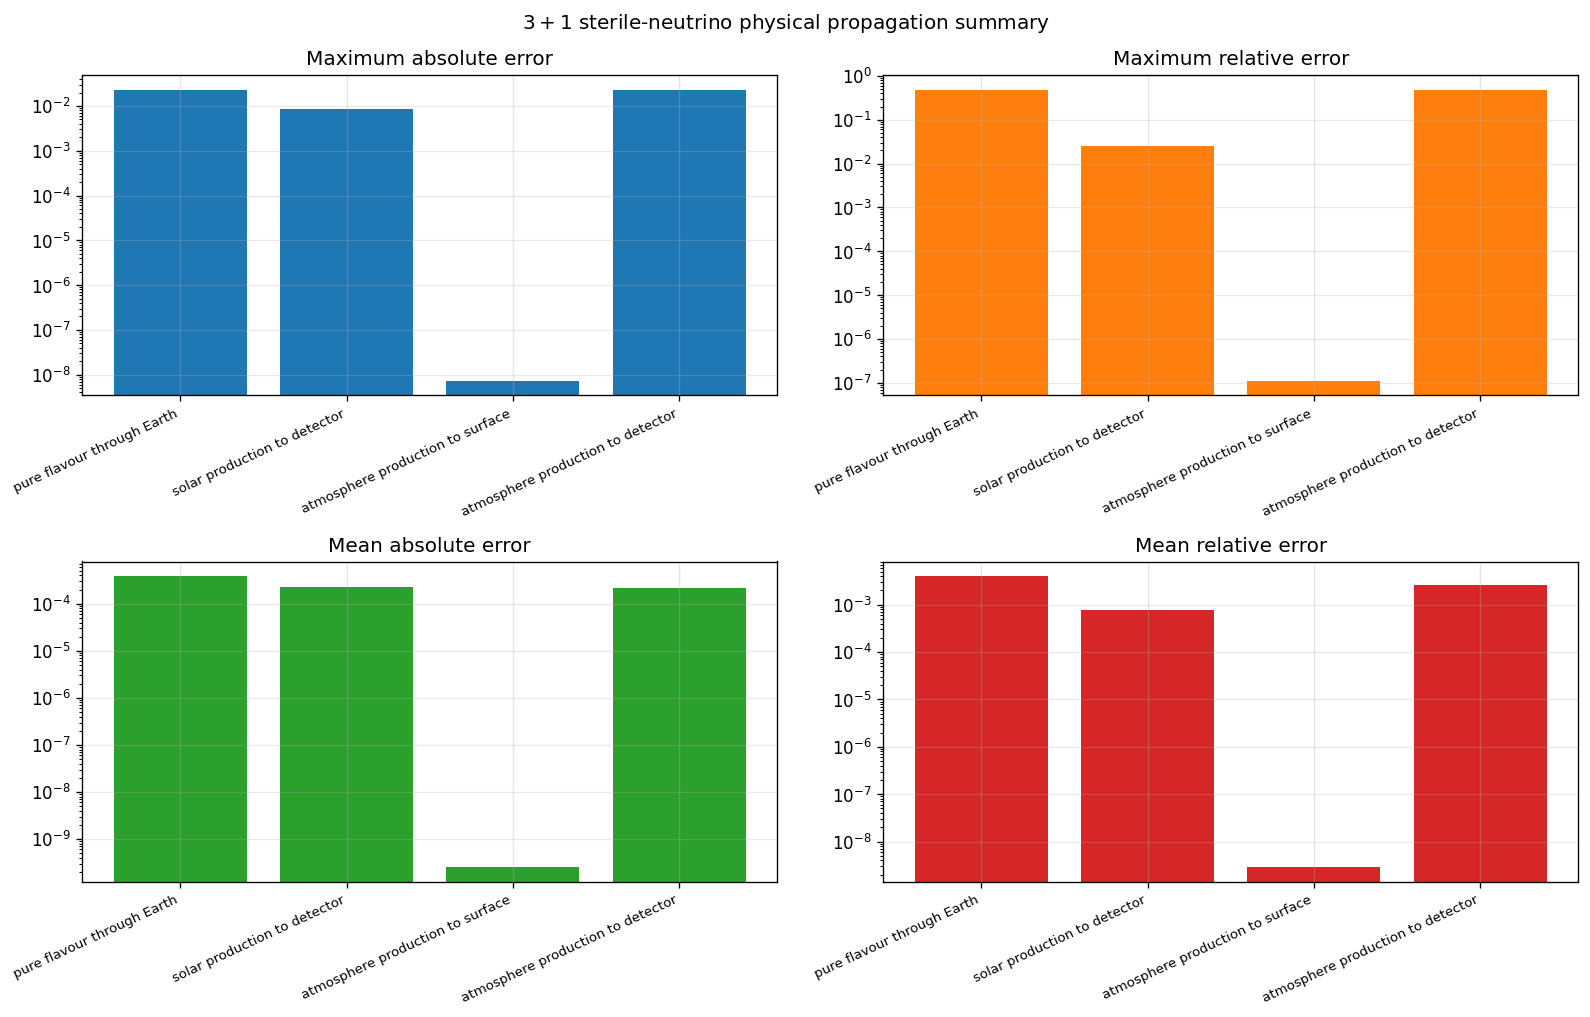

v:\output\validation\intrinsic\intrinsic3_sterile_fig8_summary.png
All four physical comparisons completed successfully.


In [11]:
summary = pd.DataFrame(summaries).set_index('case')
display(summary.style.format({column: '{:.3e}' for column in summary.select_dtypes(include='number').columns}))
summary.to_csv(OUTPUT_DIR / 'validation_intrinsic3_sterile_summary.csv')
validation_summary_plot(summaries, title='$3+1$ sterile-neutrino physical propagation summary', filename='intrinsic3_sterile_fig8_summary.png', output_dir=OUTPUT_DIR, show_plots=config.show_plots)
assert np.isfinite(summary[['max_abs','mean_abs','max_rel','mean_rel']].to_numpy()).all()
print('All four physical comparisons completed successfully.')
